# Assignment 3 - Epipolar Geometry and 3D Reconstruction 

First name: Rodrigo
<br>
Last name: Friaes
<br>
Matriculation number: 24-219-909

In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import os

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ipyvolume as ipv


from utils import  decompose_essential_matrix, infer_3d, ransac

## Part II: 3D Model Reconstruction

### Load matched points
We provide a synthetic pair of images where noisy correspondences are known.

In [2]:
left = np.array(Image.open(os.path.join('MatchedPoints','left.jpg')), dtype=np.float32).mean(2)/255
right = np.array(Image.open(os.path.join('MatchedPoints','right.jpg')), dtype=np.float32).mean(2)/255

Text(0.5, 1.0, 'Right image')

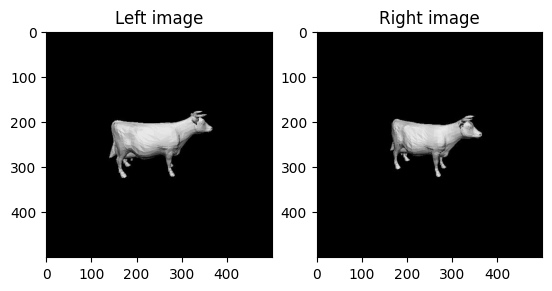

In [3]:
plt.subplot(1,2,1)
plt.imshow(left, cmap='gray')
plt.title('Left image')
plt.subplot(1,2,2)
plt.imshow(right, cmap='gray')
plt.title('Right image')

In [4]:
matriculation_number = 24219909 # TODO
A = np.loadtxt(f'MatchedPoints/Matched_Points_{matriculation_number % 50}.txt')

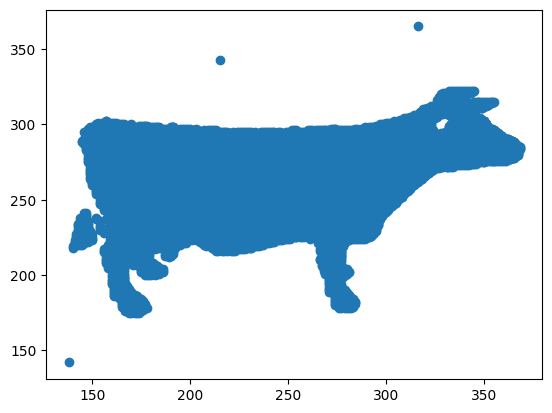

In [5]:
M, N = A.shape
leftPoints = np.concatenate((A[:,2:4].T, np.ones((1, M))), axis=0)
rightPoints = np.concatenate((A[:,0:2].T, np.ones((1, M))), axis=0)
plt.scatter(leftPoints[0, :], leftPoints[1, :])

### Calibration matrix and focal length from the given file

In [6]:
fl = 4
K = np.array([
    [-83.33333, 0.00000, 250.00000],
    [0.00000, -83.33333, 250.00000],
    [0.00000, 0.00000,   1.00000],
])

I = K.copy()

I[0,0] *= fl
I[1,1] *= fl

### Estimate Essential matrix E from F with RANSAC

In [7]:
good_threshold = 0.1  # TODO: Tune this threshold value for RANSAC

# TODO complete ransac function
F, inliers = ransac(leftPoints, rightPoints, good_threshold)
print('Num outliers', leftPoints.shape[1] - inliers.sum())
assert np.linalg.matrix_rank(F) == 2
print('Estimated fundamental matrix: ')
print(F)

# TODO: Estimate essential matrix E from F
E = I.T @ F @ I

print('Estimated essential matrix: ')
print(E)

Num outliers 10032
Estimated fundamental matrix: 
[[ 1.28781700e-06 -3.36600079e-05  1.09905518e-02]
 [ 9.74111570e-06 -8.77258283e-07  1.73658521e-02]
 [-2.83861806e-03 -9.87595890e-03 -2.43437082e+00]]
Estimated essential matrix: 
[[ 0.14309077 -3.74000058 -0.96583465]
 [ 1.0823461  -0.09747313 -6.52727188]
 [ 0.0271283   6.17009157  0.00681506]]


### Compute rotation and translation between views

In [13]:
# TODO: Compute rotation and translation between views. Complete decomposeE
# Normalize points using the calibration matrix
Il = np.linalg.solve(I, leftPoints)
Ir = np.linalg.solve(I, rightPoints)

# Decompose the essential matrix to get camera poses
Pl, Pr = decompose_essential_matrix(E, Il, Ir)

print('Estimated translation: ')
print(Pr[:,3])
print('Estimated rotation: ')
print(Pr[:,:3])

Estimated translation: 
[ 0.84931699 -0.12513724  0.51283655]
Estimated rotation: 
[[ 0.92244244  0.11843354 -0.3675234 ]
 [-0.1238016   0.99226593  0.00902721]
 [ 0.36575007  0.0371729   0.92997046]]


### Estimate the 3D points

In [14]:
x3D = infer_3d(Il, Ir, Pl, Pr)
ipv.quickscatter(x=-x3D[0,:], y=-x3D[1,:], z=-x3D[2,:])

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…